## Import main libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette("bright")

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Load Data

In [2]:
train_data = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
test_data = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")
print("train_data_shape =", train_data.shape,'\n',"test_data_shape =" ,test_data.shape) 
train_data.head()

train_data_shape = (1460, 81) 
 test_data_shape = (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


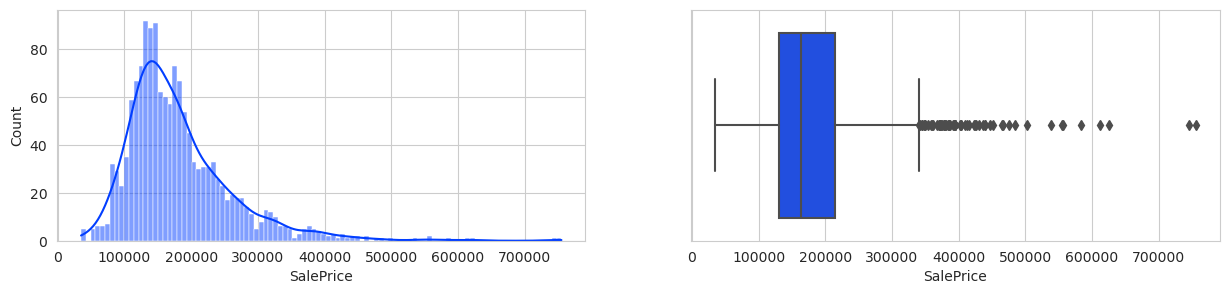

In [3]:
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2) #create a single row subplot layout with two columns
fig.set_size_inches([15,3]) #adjusts the width and height of the figure
sns.histplot(data=train_data, x='SalePrice', bins=100, kde=True, ax=ax0) #histogram plot based on SalePrice
sns.boxplot(data=train_data, x="SalePrice", ax=ax1); #box plot based on SalePrice

In [4]:
train_data["SalePrice"].describe() #descriptive statistics for the "SalePrice" column 

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## Missing & Duplicated Values

In [5]:
print("train_dup_rows = ", train_data.duplicated().sum(), #number of duplicated rows
      "test_dup_rows = ", test_data.duplicated().sum()) 

train_dup_rows =  0 test_dup_rows =  0


In [6]:
train_data.isnull().mean().sort_values(ascending=False).head(15) #top 10 missing values by %

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
FireplaceQu     0.472603
LotFrontage     0.177397
GarageYrBlt     0.055479
GarageCond      0.055479
GarageType      0.055479
GarageFinish    0.055479
GarageQual      0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtQual        0.025342
BsmtCond        0.025342
dtype: float64

In [7]:
train_data.MSSubClass = train_data.MSSubClass.astype("str") # Convert the 'MSSubClass' to string type
train_data.MoSold = train_data.MoSold.astype("str") # Convert the 'MoSold' to string type
train_data.drop("GarageYrBlt", axis=1, inplace = True) # 'GarageYrBlt' column dropped from train_data

## Feature Selection

In [8]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold # K-Folds cross-validator
from sklearn.linear_model import LinearRegression
from scipy.stats import skew

In [9]:
def get_score(data, model, cv, random_state):
    "Scores (mean_squred_error) for given data, model with cross-validation."
    
    X = data.drop("SalePrice", axis = 1) # target variable is dropped
    numeric_cols = list(X.dtypes[X.dtypes != 'O'].index) #int and float type columns of X
    
    skewed_cols = X[numeric_cols].apply(lambda x: skew(x.dropna())) #compute skewness
    skewed_cols = skewed_cols[skewed_cols > 0.75]
    skewed_cols = skewed_cols.index
    X[skewed_cols] = X[skewed_cols].astype('float').apply(np.log1p) # log1p transform for numeric columns
    
    X = pd.get_dummies(X, drop_first=True) #convert categorical variables into dummy/indicator variables
    y = data["SalePrice"].apply(np.log1p) #target variable with log transform
    
    CV = cross_validate(model, X, y, scoring='neg_mean_squared_error',
                        cv=KFold(n_splits=cv, shuffle=True, random_state=random_state),
                        return_estimator=True)
    try: #if the model is Pipeline with transformer 
        n_features = np.min([e[:-1].get_feature_names_out().size for e in CV['estimator']]) # gets number of features fitted
    except: #if model is only a model
        n_features = X.shape[1] # number of features fitted
    
    scores = [n_features, -np.mean(CV['test_score']), np.std(CV['test_score'], ddof=1)] # number of features, average mean_squared_error, std mean_squared_error

    return scores

In [10]:
# Scores will be stored in results dataframe to compare the scores.
results=pd.DataFrame([],columns=['no_feature', 'mean_cv_error','std_cv_error'])

### Data Cleaning

#### test_1: train_data_dropped

In [11]:
null_percent = train_data.isnull().mean().sort_values(ascending=False) # Calculate the percentage of missing values
drop_cols = list(null_percent[null_percent > 0.05].index) # Columns with NA values higher than %10
print("Dropped columns :", drop_cols)
train_data_dropped_cols = train_data.drop(drop_cols, axis = 1).copy() # Drop the columns
train_data_dropped = train_data_dropped_cols.dropna() # Drop rows with NA
print("train_data_dropped_shape =", train_data_dropped.shape) 

Dropped columns : ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'LotFrontage', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
train_data_dropped_shape = (1412, 70)


In [12]:
score = get_score(data = train_data_dropped, # Runs get_score function with given parameters
                  model=LinearRegression(),
                  cv=5,
                  random_state=42)
results.loc["train_data_dropped"] = score # Add score to the results DataFrame
results

,no_feature,mean_cv_error,std_cv_error
train_data_dropped,235.0,0.023688,0.009184


#### test_2: train_data_filled

In [13]:
train_data_filled = train_data.copy()
train_data_filled.PoolQC.fillna("None", inplace = True)
train_data_filled.MiscFeature.fillna("None", inplace = True)
train_data_filled.Alley.fillna("None", inplace = True)
train_data_filled.Fence.fillna("None", inplace = True)
train_data_filled.FireplaceQu.fillna("None", inplace = True)
train_data_filled.LotFrontage.fillna(0, inplace = True)
train_data_filled.GarageType.fillna("None" , inplace = True)
train_data_filled.GarageFinish.fillna("None" , inplace = True)
train_data_filled.GarageQual.fillna("None" , inplace = True)
train_data_filled.GarageCond.fillna("None" , inplace = True)
train_data_filled.BsmtQual.fillna("None" , inplace = True)
train_data_filled.BsmtCond.fillna("None" , inplace = True)
train_data_filled.BsmtExposure.fillna("None" , inplace = True)
train_data_filled.BsmtFinType1.fillna("None" , inplace = True)
train_data_filled.BsmtFinType2.fillna("None" , inplace = True)
train_data_filled.MasVnrType.fillna("None", inplace = True)
train_data_filled.MasVnrArea.fillna(0, inplace = True)
train_data_filled.Electrical.fillna("SBrkr" , inplace = True)

In [14]:
score = get_score(data = train_data_filled, # Runs get_score function with given parameters
                  random_state=42,
                  model=LinearRegression(),
                  cv=5)
results.loc["train_data_filled"] = score # Add score to the results DataFrame
results

,no_feature,mean_cv_error,std_cv_error
train_data_dropped,235.0,0.023688,0.009184
train_data_filled,282.0,0.020782,0.004197


#### test_3: train_data_drop_filled

In [15]:
print(drop_cols)

['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'LotFrontage', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']


In [16]:
train_data_drop_filled = train_data_dropped_cols.copy()
train_data_drop_filled.BsmtQual.fillna("None" , inplace = True)
train_data_drop_filled.BsmtCond.fillna("None" , inplace = True)
train_data_drop_filled.BsmtExposure.fillna("None" , inplace = True)
train_data_drop_filled.BsmtFinType1.fillna("None" , inplace = True)
train_data_drop_filled.BsmtFinType2.fillna("None" , inplace = True)
train_data_drop_filled.MasVnrType.fillna("None", inplace = True)
train_data_drop_filled.MasVnrArea.fillna(0, inplace = True)
train_data_drop_filled.Electrical.fillna("SBrkr" , inplace = True)

In [17]:
score = get_score(data = train_data_drop_filled,  # Runs get_score function with given parameters
                  random_state=42,
                  model=LinearRegression(),
                  cv=5)
results.loc["train_data_drop_filled"] = score # Add score to the results DataFrame
results

,no_feature,mean_cv_error,std_cv_error
train_data_dropped,235.0,0.023688,0.009184
train_data_filled,282.0,0.020782,0.004197
train_data_drop_filled,244.0,0.022606,0.006602


#### test_4: train_data_ordinal

In [18]:
ordered_cat = ["ExterQual", "BsmtQual", "BsmtExposure", "BsmtFinType1", "KitchenQual",
             "FireplaceQu","GarageQual", "GarageCond", "PoolQC", "Fence", "HeatingQC"]

In [19]:
train_data_ordinal = train_data_filled.copy()
for feature in ordered_cat:
    print(feature, train_data_ordinal[feature].unique(), train_data_ordinal[feature].dtype)

ExterQual ['Gd' 'TA' 'Ex' 'Fa'] object
BsmtQual ['Gd' 'TA' 'Ex' 'None' 'Fa'] object
BsmtExposure ['No' 'Gd' 'Mn' 'Av' 'None'] object
BsmtFinType1 ['GLQ' 'ALQ' 'Unf' 'Rec' 'BLQ' 'None' 'LwQ'] object
KitchenQual ['Gd' 'TA' 'Ex' 'Fa'] object
FireplaceQu ['None' 'TA' 'Gd' 'Fa' 'Ex' 'Po'] object
GarageQual ['TA' 'Fa' 'Gd' 'None' 'Ex' 'Po'] object
GarageCond ['TA' 'Fa' 'None' 'Gd' 'Po' 'Ex'] object
PoolQC ['None' 'Ex' 'Fa' 'Gd'] object
Fence ['None' 'MnPrv' 'GdWo' 'GdPrv' 'MnWw'] object
HeatingQC ['Ex' 'Gd' 'TA' 'Fa' 'Po'] object


In [20]:
for feature in ordered_cat:
    if "None" not in train_data_ordinal[feature].unique().tolist():
        train_data_ordinal[feature].replace({"Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5}, inplace=True)
        print(feature, train_data_ordinal[feature].unique(), train_data_ordinal[feature].dtype)

ExterQual [4 3 5 2] int64
KitchenQual [4 3 5 2] int64
HeatingQC [5 4 3 2 1] int64


In [21]:
score = get_score(data = train_data_ordinal,
                  random_state=42,
                  model=LinearRegression(),
                  cv=5)
results.loc["train_data_ordinal"] = score
results

,no_feature,mean_cv_error,std_cv_error
train_data_dropped,235.0,0.023688,0.009184
train_data_filled,282.0,0.020782,0.004197
train_data_drop_filled,244.0,0.022606,0.006602
train_data_ordinal,275.0,0.021134,0.004012


#### test_5: train_data_merged_cat

In [22]:
cat_features = list(train_data_ordinal.nunique()[train_data_ordinal.dtypes == 'O'].index)
print("no. cat = " , len(cat_features))
train_data_merged_cat = train_data_ordinal.copy()
print("Merged categories for each feature:")
for feature in cat_features:
    category_percent = train_data_merged_cat[feature].value_counts(normalize=True)
    others = list(category_percent[category_percent<0.01].index)
    if len(others) > 1:
        print(feature,"'others = ", others)
        train_data_merged_cat[feature].replace(others, "Other", inplace = True)

no. cat =  42
Merged categories for each feature:
MSSubClass 'others =  ['45', '180', '40']
Neighborhood 'others =  ['Veenker', 'NPkVill', 'Blueste']
Condition1 'others =  ['RRAe', 'PosA', 'RRNn', 'RRNe']
Condition2 'others =  ['Feedr', 'Artery', 'RRNn', 'PosN', 'PosA', 'RRAn', 'RRAe']
HouseStyle 'others =  ['1.5Unf', '2.5Unf', '2.5Fin']
RoofStyle 'others =  ['Flat', 'Gambrel', 'Mansard', 'Shed']
RoofMatl 'others =  ['Tar&Grv', 'WdShngl', 'WdShake', 'Metal', 'Membran', 'Roll', 'ClyTile']
Exterior1st 'others =  ['BrkComm', 'Stone', 'AsphShn', 'ImStucc', 'CBlock']
Exterior2nd 'others =  ['ImStucc', 'Brk Cmn', 'Stone', 'AsphShn', 'Other', 'CBlock']
ExterCond 'others =  ['Ex', 'Po']
Foundation 'others =  ['Stone', 'Wood']
Heating 'others =  ['Grav', 'Wall', 'OthW', 'Floor']
Electrical 'others =  ['FuseP', 'Mix']
Functional 'others =  ['Maj1', 'Maj2', 'Sev']
GarageType 'others =  ['CarPort', '2Types']
GarageQual 'others =  ['Gd', 'Ex', 'Po']
GarageCond 'others =  ['Gd', 'Po', 'Ex']
PoolQC '

In [23]:
score = get_score(data = train_data_merged_cat,
                  random_state=42,
                  model=LinearRegression(),
                  cv=5)
results.loc["train_data_merged_cat"] = score
results

,no_feature,mean_cv_error,std_cv_error
train_data_dropped,235.0,0.023688,0.009184
train_data_filled,282.0,0.020782,0.004197
train_data_drop_filled,244.0,0.022606,0.006602
train_data_ordinal,275.0,0.021134,0.004012
train_data_merged_cat,219.0,0.019353,0.005063


### Feature Selection

In [24]:
from sklearn.preprocessing import StandardScaler  # For standardizing the features
from sklearn.feature_selection import SelectKBest, f_regression  # For selecting the k best features based on f_regression
from sklearn.pipeline import make_pipeline  # For creating a data processing pipeline

#### test_6: SelectKBest

In [25]:
k_best = 150
pipe = make_pipeline(SelectKBest(f_regression, k = k_best), LinearRegression())
score = get_score(data=train_data_ordinal,
                  model=pipe,
                  cv=5,
                  random_state=42)
results.loc["SelectKBest"] = score
results

,no_feature,mean_cv_error,std_cv_error
train_data_dropped,235.0,0.023688,0.009184
train_data_filled,282.0,0.020782,0.004197
train_data_drop_filled,244.0,0.022606,0.006602
train_data_ordinal,275.0,0.021134,0.004012
train_data_merged_cat,219.0,0.019353,0.005063
SelectKBest,150.0,0.016858,0.004858


### test_data prep

In [26]:
test_data.MSSubClass = test_data.MSSubClass.astype("str") # Convert the 'MSSubClass' to string type
test_data.MoSold = test_data.MoSold.astype("str") # Convert the 'MoSold' to string type
test_data.drop("GarageYrBlt", axis=1, inplace = True) # 'GarageYrBlt' column dropped from test_data

In [27]:
test_data_filled = test_data.copy()
test_data_filled.PoolQC.fillna("None", inplace = True)
test_data_filled.MiscFeature.fillna("None", inplace = True)
test_data_filled.Alley.fillna("None", inplace = True)
test_data_filled.Fence.fillna("None", inplace = True)
test_data_filled.FireplaceQu.fillna("None", inplace = True)
test_data_filled.LotFrontage.fillna(0, inplace = True)
test_data_filled.GarageType.fillna("None" , inplace = True)
test_data_filled.GarageFinish.fillna("None" , inplace = True)
test_data_filled.GarageQual.fillna("None" , inplace = True)
test_data_filled.GarageCond.fillna("None" , inplace = True)
test_data_filled.BsmtQual.fillna("None" , inplace = True)
test_data_filled.BsmtCond.fillna("None" , inplace = True)
test_data_filled.BsmtExposure.fillna("None" , inplace = True)
test_data_filled.BsmtFinType1.fillna("None" , inplace = True)
test_data_filled.BsmtFinType2.fillna("None" , inplace = True)
test_data_filled.MasVnrType.fillna("None", inplace = True)
test_data_filled.MasVnrArea.fillna(0, inplace = True)
test_data_filled.Electrical.fillna("SBrkr" , inplace = True)

In [28]:
test_data_filled["MSZoning"].fillna("RM", inplace = True)
test_data_filled["Functional"].fillna("Typ", inplace = True)
test_data_filled["BsmtFullBath"].fillna(train_data_filled["BsmtFullBath"].mean(), inplace = True)
test_data_filled["BsmtHalfBath"].fillna(train_data_filled["BsmtHalfBath"].mean(), inplace = True)
test_data_filled["Utilities"].fillna("AllPub", inplace = True)
test_data_filled["Exterior1st"].fillna("VinylSd", inplace = True)
test_data_filled["KitchenQual"].fillna("TA", inplace = True)
test_data_filled["GarageCars"].fillna(train_data_filled["GarageCars"].mean(), inplace = True)
test_data_filled["Exterior2nd"].fillna("VinylSd", inplace = True)
test_data_filled["SaleType"].fillna("WD", inplace = True)
test_data_filled["TotalBsmtSF"].fillna(train_data_filled["TotalBsmtSF"].mean(), inplace = True)
test_data_filled["BsmtUnfSF"].fillna(train_data_filled["BsmtUnfSF"].mean(), inplace = True)
test_data_filled["BsmtFinSF2"].fillna(train_data_filled["BsmtFinSF2"].mean(), inplace = True)
test_data_filled["BsmtFinSF1"].fillna(train_data_filled["BsmtFinSF1"].mean(), inplace = True)
test_data_filled["GarageArea"].fillna(train_data_filled["GarageArea"].mean(), inplace = True)

In [29]:
test_data_ordinal = test_data_filled.copy()
for feature in ordered_cat:
    if "None" not in test_data_ordinal[feature].unique().tolist():
        test_data_ordinal[feature].replace({"Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5}, inplace=True)
        print(feature, test_data_ordinal[feature].unique(), test_data_ordinal[feature].dtype)

ExterQual [3 4 5 2] int64
KitchenQual [3 4 5 2] int64
HeatingQC [3 4 5 2 1] int64


## Result

In [30]:
X_train = train_data_ordinal.drop("SalePrice", axis = 1) # target variable is dropped
numeric_cols = list(X_train.dtypes[X_train.dtypes != 'O'].index) #int and float type columns of X
skewed_cols = X_train[numeric_cols].apply(lambda x: skew(x)) #compute skewness
skewed_cols = skewed_cols[skewed_cols > 0.75]
skewed_cols = skewed_cols.index
X_train[skewed_cols] = X_train[skewed_cols].astype('float').apply(np.log1p) # log1p transform for numeric columns
X_train = pd.get_dummies(X_train) #convert categorical variables into dummy/indicator variables
y_train = train_data_ordinal["SalePrice"].apply(np.log1p) #target variable with log transform

In [31]:
skewed_cols = test_data_ordinal[numeric_cols].apply(lambda x: skew(x)) #compute skewness
skewed_cols = skewed_cols[skewed_cols > 0.75]
skewed_cols = skewed_cols.index
test_data_ordinal[skewed_cols] = test_data_ordinal[skewed_cols].apply(np.log1p).astype('float') # log1p transform for numeric columns

X_test = pd.get_dummies(test_data_ordinal) #convert categorical variables into dummy/indicator variables
X_test.drop("MSSubClass_150", axis=1, inplace=True)

In [32]:
X_train = X_train[X_test.columns]
selector = SelectKBest(f_regression, k = 150)
selector.fit(X_train, y_train)

X_test_best = selector.transform(X_test)
X_train_best = selector.transform(X_train)

model = LinearRegression()
model.fit(X_train_best, y_train)

X_test["SalePrice"] = np.exp(model.predict(X_test_best))
X_test.reset_index(inplace=True)
result = X_test[["Id","SalePrice"]]

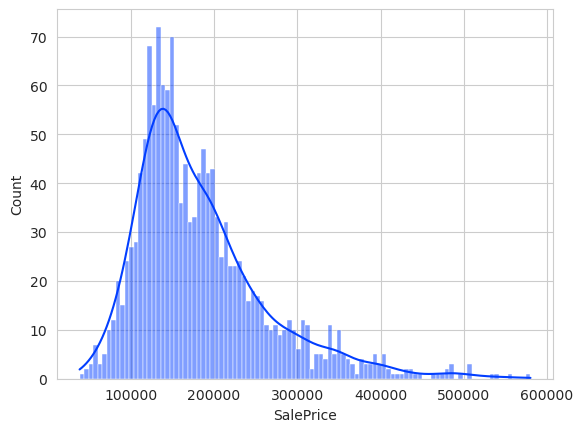

In [33]:
sns.histplot(data=result, x="SalePrice", bins=100, kde=True);

In [34]:
result.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
